# Slow and Steady 💧
### Is dollar-cost averaging really safer *and* smarter than investing the lump sum?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Lowers risk?: Confirmed](https://img.shields.io/badge/Lowers_risk%3F-Confirmed-8b949e?style=flat-square)

When you come into money — a bonus, an inheritance, a 401(k) rollover — the advice is almost always *"don't put it all in at once; spread it in over a year."* We take that literally on 30+ years of SPY and ask the only two questions that matter: does drip-feeding **lower your risk** (yes), and does it **beat going all-in** (no — by a mile).

> 📓 **This is the plain-language layer.** The win-rate confidence interval, the overlap-corrected *t*-stat and the exposure-vs-timing maths are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Educational, reproducible research — every chart below is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (slow_and_steady/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from slow_and_steady import data, strategy

AS_OF = "2026-06-12"
frame = data.load_real("SPY", mode="total_return").loc[:AS_OF]
close = frame["close"]
race = strategy.rolling_race(close, deploy_months=12, step=1)
s = strategy.win_stats(race)
hac_t = strategy.hac_tstat(race["ls_minus_dca"].to_numpy())
print(f"SPY total return: {len(close):,} rows  {close.index[0].date()} -> {close.index[-1].date()}  fingerprint={data.fingerprint(frame)}")
print(f"{s['n_windows']:,} rolling windows | lump-sum wins {s['ls_win_rate']*100:.1f}% | mean gap {s['mean_gap']*100:+.2f} cents/$1 | HAC t {hac_t:+.2f}")
print(f"dispersion: LS std {s['ls_std']:.4f} vs DCA std {s['dca_std']:.4f} (ratio {s['dispersion_ratio']:.3f})")


SPY total return: 8,400 rows  1993-01-29 -> 2026-06-12  fingerprint=eb1569cc9e97
8,168 rolling windows | lump-sum wins 78.6% | mean gap +5.60 cents/$1 | HAC t +16.96
dispersion: LS std 0.1587 vs DCA std 0.0850 (ratio 0.536)


## The answer first 🎯

| Question | Answer |
|---|---|
| Does DCA beat investing it all at once? | **No** — across **8,168** rolling 12-month windows the lump sum finishes richer **78.6%** of the time. |
| By how much? | **+5.6 cents on every dollar**, on average. |
| Does DCA lower your risk? | **Yes** — its range of outcomes is about **half** as wide (spread 0.085 vs 0.159), and its worst year loses **-37.5%** vs **-49.3%**. |
| So what *is* DCA? | A way to take **less risk** by staying **less invested** — not a way to make more money. |

## 1 · The claim

*"Don't invest a windfall all at once. Dollar-cost average it in — buy a fixed amount each month for a year. You'll buy at a lower average price, you'll lower your risk, and you'll come out ahead of going all-in."* It's the default advice of almost every personal-finance column and robo-advisor.

## 2 · So what?

Trillions of dollars move on this rule — every rollover, every bonus, every inheritance. If spreading-in really beat lump-summing, you'd be leaving free money on the table by going all-in. So it deserves a fair, literal test on real data — not a chart cherry-picked to a crash.

## 3 · How would we even know?

For **every** day in 30+ years of SPY (dividends included), we run two \$1 plans starting that day: **lump-sum** (all in today) and **DCA** (12 equal monthly buys over the next year, the waiting cash earning 0% — which actually *helps* DCA's case). We value both at the **same** end date and see who's richer. If DCA were smarter, it would win most of the time. It doesn't.

## 4 · The teardown — let's actually look

First, **who finishes richer?** A histogram of the lump-sum-minus-DCA gap across every window — bars to the right of zero are windows the lump sum won.

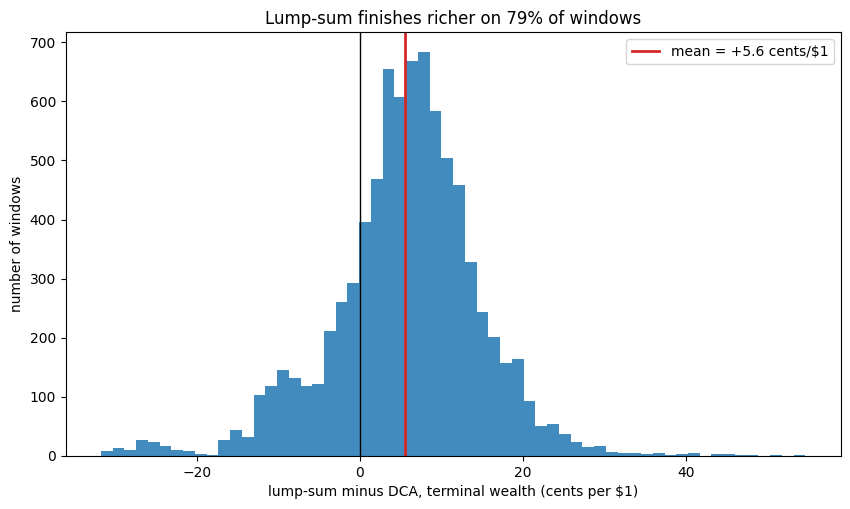

lump-sum wins 78.6% of 8,168 windows


In [2]:
gap = race['ls_minus_dca'].to_numpy() * 100  # cents per $1
ls_wins = (gap > 0).mean() * 100
plt.hist(gap, bins=60, alpha=.85)
plt.axvline(0, color='k', lw=1)
plt.axvline(gap.mean(), color='C3', lw=2, label=f'mean = {gap.mean():+.1f} cents/$1')
plt.xlabel('lump-sum minus DCA, terminal wealth (cents per $1)')
plt.ylabel('number of windows')
plt.title(f'Lump-sum finishes richer on {ls_wins:.0f}% of windows')
plt.legend(); plt.show()
print(f'lump-sum wins {ls_wins:.1f}% of {len(gap):,} windows')

The mass sits firmly to the **right** of zero: the lump sum wins **78.6%** of windows. DCA only wins the windows on the left — the ones where the market *fell* over the deployment year, so buying in slowly happened to buy cheaper.

Now the **risk** angle — the thing DCA really does buy. Here are the two arms' terminal-wealth distributions side by side.

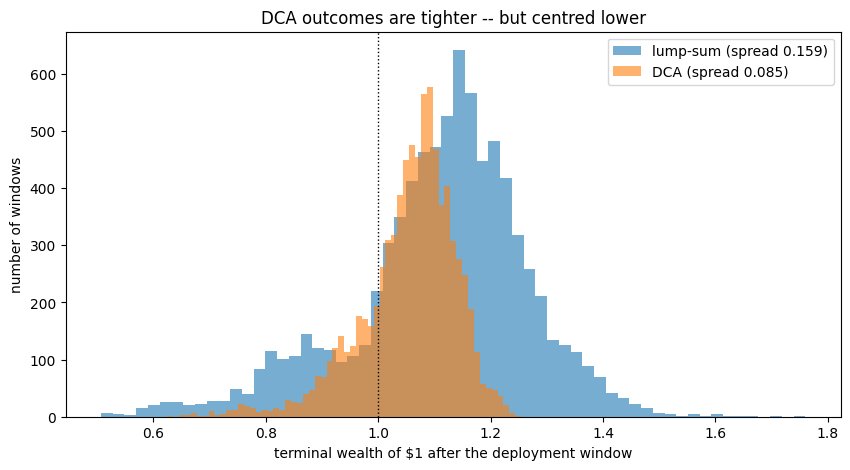

worst window: lump-sum 0.507  DCA 0.625


In [3]:
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(race['lump_sum'], bins=60, alpha=.6, label=f"lump-sum (spread {race['lump_sum'].std():.3f})")
ax.hist(race['dca'], bins=60, alpha=.6, label=f"DCA (spread {race['dca'].std():.3f})")
ax.axvline(1.0, color='k', lw=1, ls=':')
ax.set_xlabel('terminal wealth of $1 after the deployment window')
ax.set_ylabel('number of windows'); ax.legend()
ax.set_title('DCA outcomes are tighter -- but centred lower'); plt.show()
print(f"worst window: lump-sum {race['lump_sum'].min():.3f}  DCA {race['dca'].min():.3f}")

DCA's bell is **narrower** (spread 0.085 vs 0.159) and its worst case is shallower (-37.5% vs -49.3%) — that's the real risk reduction. But the whole curve is shifted **left**: you paid for the calmer ride with return.

## 5 · The verdict

- **Lowers risk? → Confirmed.** DCA's outcome spread is little over half the lump sum's (ratio 0.536), worst case -37.5% vs -49.3%.
- **Beats a lump sum? → No (Signal: None).** The lump sum wins **78.6%** of windows by **+5.6 cents/\$1** — overwhelming, not noise.
- **The *smarter* way to invest? → Mirage.** The only thing DCA buys is lower exposure to the very returns it then misses out on.

## 6 · Could you actually trade it?

There's nothing to *trade* — it's a deployment schedule, not a strategy. And as a schedule it loses: the lump sum's average win of **+5.6 cents on the dollar** is exactly the equity premium your idle cash forfeits while it "averages in." If you genuinely want the calmer ride, deploy the lump sum and just hold a **smaller stock weight** — same lower risk, no opportunity cost on cash that's sitting out.

## 7 · Going further 🚪

- Let the waiting cash earn the **T-bill** instead of 0%. It shrinks the gap a little — but DCA still loses, because the equity premium beats the bill on average.
- Vary the deployment horizon (6, 24 months): does a *longer* drip lose by *more*?
- The real DCA most people do is *involuntary* (a paycheck each month) — that's a savings rate, not a lump-vs-DCA choice. Fork it and separate the two.